# Making the linear part explicit

Notebook 2 established that the rollout loss does not determine sigma. The growth rate is read
as $\partial f_\theta/\partial z$ at $z = 0$, a point with no data, and the loss grades where
an 8 step rollout lands rather than the slope at any point. Sigma drifts freely, is unrelated to
generalisation, and is not fixed by reweighting.

This notebook tries the structural fix. Split the field into a linear part and a residual that
vanishes to second order, so sigma becomes a parameter instead of a derivative of a black box.

$$\dot z = A z + g_\theta(z), \qquad
  g_\theta(z) = h_\theta(z) - h_\theta(0) - J_h(0)\, z$$

Setup below is copied from notebook 2 so this runs on its own. Same data, same scaling, same
windows, same optimiser, same cache.

## Setup

In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

DATA = Path('../data')
R, DT, L = 8, 0.399, 8
RE, SIGMA_MEAS = 73.0, 0.0903            # measured growth rate at Re = 73 (growth.py)

d = np.load(DATA / f'latent_r{R}.npz')

def load(Re_value):
    # trajectories at one Reynolds number, scaled by ONE global factor
    m = d['Re'] == Re_value
    a_raw, traj = d['a'][m], d['traj'][m]
    S = float(a_raw.std())
    runs = [a_raw[traj == j] / S for j in np.unique(traj)]
    return runs, a_raw, S

runs, a_raw, S = load(RE)
print(f'Re = {RE:g}:  outward {len(runs[0])} snapshots, inward {len(runs[1])}, '
      f'total {len(a_raw)}')
print(f'that is {a_raw.size:,} floats -- about {a_raw.nbytes/1024:.0f} KB of training data')

Re = 73:  outward 349 snapshots, inward 175, total 524
that is 4,192 floats -- about 16 KB of training data


In [2]:
def windows_of(runs):
    return jnp.asarray(np.stack([r[k:k + L + 1] for r in runs for k in range(len(r) - L)]),
                       dtype=jnp.float64)

W = windows_of(runs)
print(f'{W.shape[0]} windows of {L} steps ({L*DT:.1f} convective times each)')

n_out = np.linalg.norm(runs[0], axis=1)
A_sat = n_out[int(0.75 * len(n_out)):].mean()
for frac in (0.05, 0.10, 0.25):
    k = (n_out < frac * A_sat).sum()
    print(f'  outward snapshots with |z| < {frac:.0%} of limit-cycle amplitude: '
          f'{k:4d}  ({100*k/len(n_out):.0f}%)')

508 windows of 8 steps (3.2 convective times each)
  outward snapshots with |z| < 5% of limit-cycle amplitude:   29  (8%)
  outward snapshots with |z| < 10% of limit-cycle amplitude:   41  (12%)
  outward snapshots with |z| < 25% of limit-cycle amplitude:   61  (17%)


In [3]:
LAYERS = [R, 64, 64, R]
SEEDS = (0, 1, 2, 3, 4)
N_STEPS = 12000
CHECKPOINTS = (1000, 2000, 4000, 8000, 12000)

def init_params(key):
    params = []
    for n_in, n_out_ in zip(LAYERS[:-1], LAYERS[1:]):
        key, k = jax.random.split(key)
        params.append((jax.random.normal(k, (n_in, n_out_)) * jnp.sqrt(1.0 / n_in),
                       jnp.zeros(n_out_)))
    return params

def g(params, z):
    h = z
    for Wm, b in params[:-1]:
        h = jnp.tanh(h @ Wm + b)
    Wm, b = params[-1]
    return h @ Wm + b

def f(params, z):
    return g(params, z) - g(params, jnp.zeros(R, z.dtype))   # f(0) = 0 exactly

print('parameters:', sum(Wm.size + b.size for Wm, b in init_params(jax.random.PRNGKey(0))))

parameters: 5256


In [4]:
SUBSTEPS = 2

def rk4_step(params, z, dt):
    k1 = f(params, z)
    k2 = f(params, z + 0.5 * dt * k1)
    k3 = f(params, z + 0.5 * dt * k2)
    k4 = f(params, z + dt * k3)
    return z + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def step(params, z):
    for _ in range(SUBSTEPS):
        z = rk4_step(params, z, DT / SUBSTEPS)
    return z

def rollout(params, z0, n):
    _, tr = jax.lax.scan(lambda z, _: (step(params, z),) * 2, z0, None, length=n)
    return jnp.concatenate([z0[None], tr])

def jacobian(p):
    # the learned linearisation at the origin
    return np.asarray(jax.jacfwd(lambda z: f(p, z))(jnp.zeros(R)))

def spectrum(p):
    return np.linalg.eigvals(jacobian(p))

def leading_eig(p, complex_only=True):
    # A Hopf bifurcation is a complex-conjugate pair crossing the imaginary axis,
    # so restrict to oscillatory eigenvalues unless explicitly asked not to.
    ev = spectrum(p)
    idx = np.where(np.abs(ev.imag) > 1e-6)[0] if complex_only else np.arange(len(ev))
    if len(idx) == 0:
        return np.nan, np.nan, ev
    k = idx[int(np.argmax(ev.real[idx]))]
    return ev[k].real, abs(ev[k].imag), ev

In [5]:
def adam_update(p, grads, m, v, i, lr, b1=0.9, b2=0.999, eps=1e-8):
    m = jax.tree.map(lambda m_, g_: b1 * m_ + (1 - b1) * g_, m, grads)
    v = jax.tree.map(lambda v_, g_: b2 * v_ + (1 - b2) * g_ * g_, v, grads)
    mh = jax.tree.map(lambda m_: m_ / (1 - b1 ** i), m)
    vh = jax.tree.map(lambda v_: v_ / (1 - b2 ** i), v)
    return jax.tree.map(lambda p_, m_, v_: p_ - lr * m_ / (jnp.sqrt(v_) + eps), p, mh, vh), m, v

CACHE = Path('node_fits.pkl')
_cache = pickle.load(open(CACHE, 'rb')) if CACHE.exists() else {}
print(f'{len(_cache)} fits in {CACHE}')

from IPython.display import Markdown, display

def table(header, align, rows, caption=None):
    md_ = ('| ' + ' | '.join(header) + ' |\n|' + '|'.join(align) + '|\n'
           + '\n'.join('| ' + ' | '.join(r) + ' |' for r in rows))
    display(Markdown(md_ + (f'\n\n{caption}' if caption else '')))

# the plain NODE at 15k, trained in notebook 2, kept here as the comparison baseline
plain_tracks = {s: _cache[f'Re{RE:g}_mb128_L9_seed{s}_15000'][1] for s in range(5)}
_b = np.array([plain_tracks[s][15000][0] for s in range(5)])
print(f'plain NODE baseline, 5 seeds at 15k: sigma {_b.mean():+.4f} '
      f'({100*(_b.mean()-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%), spread {np.ptp(_b):.4f}')

78 fits in node_fits.pkl
plain NODE baseline, 5 seeds at 15k: sigma +0.0905 (+0%), spread 0.0066


## Making the linear part an explicit parameter

Sigma is currently a derivative of a black box at a point with no data. Make it a parameter
instead:

$$\dot z = A z + g_\theta(z), \qquad g_\theta(z) = h_\theta(z) - h_\theta(0) - J_h(0)\, z$$

$g$ vanishes to second order by construction, so $\partial f/\partial z|_0 = A$ exactly and
sigma is just the leading oscillatory eigenvalue of $A$. Nothing is differentiated out of the
network to get it.

$h_\theta(0)$ and $J_h(0)$ depend only on the weights, not on $z$, so they are computed once
per step and reused across the batch and all rollout steps.

Nothing else added yet. No penalty keeping $g$ small near the origin, no freezing, no ridge.
Two starting points for $A$:

- cold, $A = 0$, no prior information
- warm, $A$ from least squares on the near origin snapshots

Trainable in both cases. If warm starts right and training pulls it away, that says the rollout
loss prefers a wrong $A$.

In [6]:
LIN_SEEDS = (0, 1, 2)
LIN_STEPS = 15000
LIN_EVERY = 50

# least-squares A on the near-origin snapshots, in the same scaled units the model uses
_a = d['a'][d['Re'] == RE] / S
_ad = d['adot'][d['Re'] == RE] / S
_amp = np.linalg.norm(_a, axis=1)
_sel = _amp < 0.94                                  # matches the raw |a| < 0.5 cut
A_LS = np.linalg.lstsq(_a[_sel], _ad[_sel], rcond=None)[0].T
def _sig_of(M):
    ev = np.linalg.eigvals(M); o = ev[np.abs(ev.imag) > 1e-6]
    if len(o) == 0: return np.nan, np.nan
    k = o[np.argmax(o.real)]; return k.real, abs(k.imag) / (2*np.pi)
_s, _f = _sig_of(A_LS)
print(f'least squares A on {int(_sel.sum())} snapshots: sigma {_s:+.4f} '
      f'({100*(_s-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%), f {_f:.4f}')
print(f'  eigenvalues: ' + '  '.join(f'{v.real:+.2f}{v.imag:+.2f}j' for v in
                                     np.linalg.eigvals(A_LS)))
print(f'  max |lambda|*dt = {np.abs(np.linalg.eigvals(A_LS)).max()*DT/SUBSTEPS:.2f}  '
      f'(RK4 limit 2.79)')

def h_net(hp, z):
    x = z
    for Wm, b in hp[:-1]:
        x = jnp.tanh(x @ Wm + b)
    Wm, b = hp[-1]
    return x @ Wm + b

def h_consts(hp):
    z0 = jnp.zeros(R)
    return h_net(hp, z0), jax.jacfwd(lambda z: h_net(hp, z))(z0)

def f_lin(prm, z, h0, J0):
    return prm['A'] @ z + h_net(prm['h'], z) - h0 - J0 @ z

def rk4_lin(prm, z, dt, h0, J0):
    k1 = f_lin(prm, z, h0, J0)
    k2 = f_lin(prm, z + .5*dt*k1, h0, J0)
    k3 = f_lin(prm, z + .5*dt*k2, h0, J0)
    k4 = f_lin(prm, z + dt*k3, h0, J0)
    return z + (dt/6.)*(k1 + 2*k2 + 2*k3 + k4)

def step_lin(prm, z, h0, J0):
    for _ in range(SUBSTEPS):
        z = rk4_lin(prm, z, DT/SUBSTEPS, h0, J0)
    return z

def rollout_lin(prm, z0, n, h0, J0):
    _, t = jax.lax.scan(lambda z, _: (step_lin(prm, z, h0, J0),)*2, z0, None, length=n)
    return jnp.concatenate([z0[None], t])

def loss_lin(prm, wins):
    h0, J0 = h_consts(prm['h'])
    pred = jax.vmap(lambda w: rollout_lin(prm, w[0], L, h0, J0))(wins)
    return jnp.mean((pred - wins) ** 2)

@jax.jit
def train_step_lin(prm, wins, m, v, i, lr):
    loss, grads = jax.value_and_grad(loss_lin)(prm, wins)
    prm, m, v = adam_update(prm, grads, m, v, i, lr)
    return prm, m, v, loss

def init_lin(key, warm):
    hp = init_params(key)
    A0 = jnp.asarray(A_LS, dtype=jnp.float64) if warm else jnp.zeros((R, R))
    return {'A': A0, 'h': hp}

def train_lin(seed, warm, n_steps=LIN_STEPS, batch=128, every=LIN_EVERY):
    prm = init_lin(jax.random.PRNGKey(seed), warm)
    key = jax.random.PRNGKey(seed + 10_000)
    m = jax.tree.map(jnp.zeros_like, prm)
    v = jax.tree.map(jnp.zeros_like, prm)
    n, track = W.shape[0], {}
    for i in range(1, n_steps + 1):
        key, sub = jax.random.split(key)
        idx = jax.random.permutation(sub, n)[:batch]
        lr = 3e-3 if i <= 0.5*n_steps else (1e-3 if i <= 0.8*n_steps else 2e-4)
        prm, m, v, loss = train_step_lin(prm, W[idx], m, v, float(i), lr)
        if i % every == 0:
            sg, fr = _sig_of(np.asarray(prm['A']))
            track[i] = (float(sg), float(fr), float(loss))
    return prm, track

lin_tracks = {}
for warm in (False, True):
    tag = 'warm' if warm else 'cold'
    for s in LIN_SEEDS:
        key = f'Re{RE:g}_linA_{tag}_seed{s}_{LIN_STEPS}'
        if key in _cache:
            _, lin_tracks[(tag, s)] = _cache[key]
            print(f'[{key}] cached')
        else:
            print(f'training {key} ...', flush=True)
            prm, trk = train_lin(s, warm)
            _cache[key] = (prm, trk); lin_tracks[(tag, s)] = trk
            with open(CACHE, 'wb') as fh:
                pickle.dump(_cache, fh)
        t = lin_tracks[(tag, s)][LIN_STEPS]
        print(f'   {tag} seed {s}: sigma {t[0]:+.4f} '
              f'({100*(t[0]-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%)  f {t[1]:.4f}', flush=True)
print('done')

least squares A on 65 snapshots: sigma +0.0946 (+5%), f 0.1337
  eigenvalues: +0.09+0.84j  +0.09-0.84j  +0.04+0.72j  +0.04-0.72j  -0.13+0.18j  -0.13-0.18j  +0.19+0.00j  +0.06+0.00j
  max |lambda|*dt = 0.17  (RK4 limit 2.79)
[Re73_linA_cold_seed0_15000] cached
   cold seed 0: sigma +0.1486 (+65%)  f 0.1136


[Re73_linA_cold_seed1_15000] cached
   cold seed 1: sigma +0.0024 (-97%)  f 0.0545


[Re73_linA_cold_seed2_15000] cached
   cold seed 2: sigma +0.1369 (+52%)  f 0.0729


[Re73_linA_warm_seed0_15000] cached
   warm seed 0: sigma +0.1004 (+11%)  f 0.1380


[Re73_linA_warm_seed1_15000] cached
   warm seed 1: sigma +0.1106 (+23%)  f 0.1367


[Re73_linA_warm_seed2_15000] cached
   warm seed 2: sigma +0.1005 (+11%)  f 0.1365


done


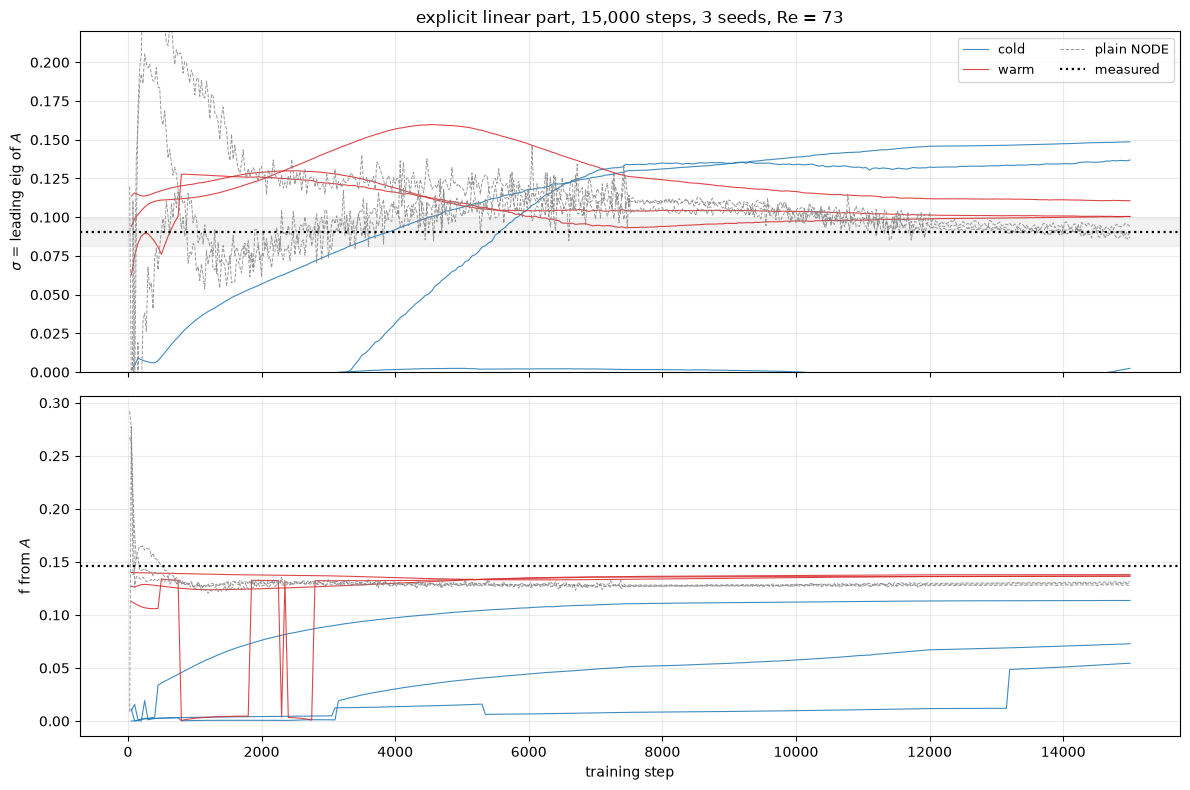

| model | mean sigma | bias | seed spread | mean f | f bias |
|---:|---:|---:|---:|---:|---:|
| plain NODE | +0.0907 | +0% | 0.0066 | 0.1301 | -11% |
| explicit A, cold | +0.0960 | +6% | 0.1462 | 0.0803 | -45% |
| explicit A, warm | +0.1038 | +15% | 0.0103 | 0.1371 | -6% |
| least squares A only | +0.0946 | +5% | — | 0.1337 | -9% |

measured sigma +0.0903, measured f 0.1462

In [7]:
F_LIN_MEAS = 0.1462
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
sty = {'cold': dict(color='C0'), 'warm': dict(color='C3')}
for tag in ('cold', 'warm'):
    for s in LIN_SEEDS:
        st = np.array(sorted(lin_tracks[(tag, s)]))
        lab = tag if s == LIN_SEEDS[0] else None
        ax[0].plot(st, [lin_tracks[(tag, s)][k][0] for k in st], lw=0.8, alpha=0.85,
                   label=lab, **sty[tag])
        ax[1].plot(st, [lin_tracks[(tag, s)][k][1] for k in st], lw=0.8, alpha=0.85, **sty[tag])
for s in LIN_SEEDS:                                   # the plain model, for comparison
    st = np.array(sorted(plain_tracks[s]))
    ax[0].plot(st, [plain_tracks[s][k][0] for k in st], color='0.5', lw=0.7, ls='--',
               alpha=0.8, label='plain NODE' if s == LIN_SEEDS[0] else None)
    ax[1].plot(st, [plain_tracks[s][k][1] for k in st], color='0.5', lw=0.7, ls='--', alpha=0.8)
ax[0].axhline(SIGMA_MEAS, color='k', ls=':', lw=1.6, label='measured')
ax[0].axhspan(0.9*SIGMA_MEAS, 1.1*SIGMA_MEAS, color='0.6', alpha=0.12)
ax[1].axhline(F_LIN_MEAS, color='k', ls=':', lw=1.6)
ax[0].set_ylabel(r'$\sigma$ = leading eig of $A$'); ax[0].set_ylim(0.0, 0.22)
ax[1].set_ylabel('f from $A$'); ax[1].set_xlabel('training step')
ax[0].legend(fontsize=9, ncol=2)
ax[0].set_title(f'explicit linear part, {LIN_STEPS:,} steps, {len(LIN_SEEDS)} seeds, Re = {RE:g}')
for a in ax: a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

rows = []
plain = np.array([plain_tracks[s][15000][0] for s in LIN_SEEDS])
plainf = np.array([plain_tracks[s][15000][1] for s in LIN_SEEDS])
rows.append(['plain NODE', f'{plain.mean():+.4f}', f'{100*(plain.mean()-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%',
             f'{np.ptp(plain):.4f}', f'{plainf.mean():.4f}',
             f'{100*(plainf.mean()-F_LIN_MEAS)/F_LIN_MEAS:+.0f}%'])
for tag in ('cold', 'warm'):
    v = np.array([lin_tracks[(tag, s)][LIN_STEPS][0] for s in LIN_SEEDS])
    fv = np.array([lin_tracks[(tag, s)][LIN_STEPS][1] for s in LIN_SEEDS])
    rows.append([f'explicit A, {tag}', f'{v.mean():+.4f}',
                 f'{100*(v.mean()-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%', f'{np.ptp(v):.4f}',
                 f'{fv.mean():.4f}', f'{100*(fv.mean()-F_LIN_MEAS)/F_LIN_MEAS:+.0f}%'])
rows.append(['least squares A only', f'{_s:+.4f}',
             f'{100*(_s-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%', '—', f'{_f:.4f}',
             f'{100*(_f-F_LIN_MEAS)/F_LIN_MEAS:+.0f}%'])
table(['model', 'mean sigma', 'bias', 'seed spread', 'mean f', 'f bias'], ['---:']*6, rows,
      caption=f'measured sigma {SIGMA_MEAS:+.4f}, measured f {F_LIN_MEAS:.4f}')

### Keeping the residual small near the origin

Explicit $A$ alone was not enough. Measured on the warm fits, $\|g\|$ is 12 to 26 percent of
$\|Az\|$ inside $\|z\| < 0.3$, so the residual is still a quarter of the field in the region
where the truth is linear to within 0.6 percent. That is how $A$ gets dragged away from the
least squares answer.

Add a term that forbids it:

$$\mathcal{L} = \text{rollout MSE} + \lambda \, \mathbb{E}_{\|z\| < 0.3} \|g_\theta(z)\|^2$$

Points are drawn uniformly in the ball each step. Lambda of 0.02 makes the penalty about the
same size as the main loss, so 0.2 and 2.0 lean on it harder. Warm start only, since cold
failed. Three seeds, 50k steps, because the question is whether sigma stops drifting and the
drift only shows up on a long run.

In [8]:
PEN_R = 0.3
PEN_N = 256
PEN_LAMBDA = 0.2                        # penalty weight, 10x the level that
PEN_LAMBDAS = (PEN_LAMBDA,)             # matches the main loss
PEN_SEEDS = (0, 1, 2)
PEN_STEPS = 50000
PEN_EVERY = 100

def sample_ball(key, n, r):
    k1, k2 = jax.random.split(key)
    u = jax.random.normal(k1, (n, R))
    u = u / jnp.linalg.norm(u, axis=1, keepdims=True)
    rad = r * jax.random.uniform(k2, (n, 1)) ** (1.0 / R)
    return u * rad

def loss_pen(prm, wins, zs, lam):
    h0, J0 = h_consts(prm['h'])
    pred = jax.vmap(lambda w: rollout_lin(prm, w[0], L, h0, J0))(wins)
    main = jnp.mean((pred - wins) ** 2)
    g = jax.vmap(lambda z: h_net(prm['h'], z) - h0 - J0 @ z)(zs)
    pen = jnp.mean(jnp.sum(g ** 2, axis=1))
    return main + lam * pen, (main, pen)

@jax.jit
def train_step_pen(prm, wins, zs, lam, m, v, i, lr):
    (tot, (main, pen)), grads = jax.value_and_grad(loss_pen, has_aux=True)(prm, wins, zs, lam)
    prm, m, v = adam_update(prm, grads, m, v, i, lr)
    return prm, m, v, main, pen

def train_pen(seed, lam, n_steps=PEN_STEPS, batch=128, every=PEN_EVERY):
    prm = init_lin(jax.random.PRNGKey(seed), warm=True)
    key = jax.random.PRNGKey(seed + 10_000)
    m = jax.tree.map(jnp.zeros_like, prm)
    v = jax.tree.map(jnp.zeros_like, prm)
    n, track = W.shape[0], {}
    for i in range(1, n_steps + 1):
        key, sub, sub2 = jax.random.split(key, 3)
        idx = jax.random.permutation(sub, n)[:batch]
        zs = sample_ball(sub2, PEN_N, PEN_R)
        lr = 3e-3 if i <= 0.5*n_steps else (1e-3 if i <= 0.8*n_steps else 2e-4)
        prm, m, v, main, pen = train_step_pen(prm, W[idx], zs, lam, m, v, float(i), lr)
        if i % every == 0:
            sg, fr = _sig_of(np.asarray(prm['A']))
            track[i] = (float(sg), float(fr), float(main), float(pen))
    return prm, track

pen_tracks = {}
for lam in PEN_LAMBDAS:
    for s in PEN_SEEDS:
        key = f'Re{RE:g}_pen{lam}_seed{s}_{PEN_STEPS}'
        if key in _cache:
            _, pen_tracks[(lam, s)] = _cache[key]
            print(f'[{key}] cached')
        else:
            print(f'training lambda={lam} seed {s} ...', flush=True)
            prm, trk = train_pen(s, lam)
            _cache[key] = (prm, trk); pen_tracks[(lam, s)] = trk
            with open(CACHE, 'wb') as fh:
                pickle.dump(_cache, fh)
        t = pen_tracks[(lam, s)][PEN_STEPS]
        print(f'   lambda {lam}  seed {s}: sigma {t[0]:+.4f} '
              f'({100*(t[0]-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%)  f {t[1]:.4f}  '
              f'main {t[2]:.2e}  pen {t[3]:.2e}', flush=True)
print('done')

[Re73_pen0.2_seed0_50000] cached
   lambda 0.2  seed 0: sigma +0.1123 (+24%)  f 0.1374  main 1.20e-05  pen 6.81e-06


[Re73_pen0.2_seed1_50000] cached
   lambda 0.2  seed 1: sigma +0.1143 (+27%)  f 0.1375  main 1.48e-05  pen 9.08e-06


[Re73_pen0.2_seed2_50000] cached
   lambda 0.2  seed 2: sigma +0.1035 (+15%)  f 0.1380  main 7.37e-06  pen 7.47e-06


done


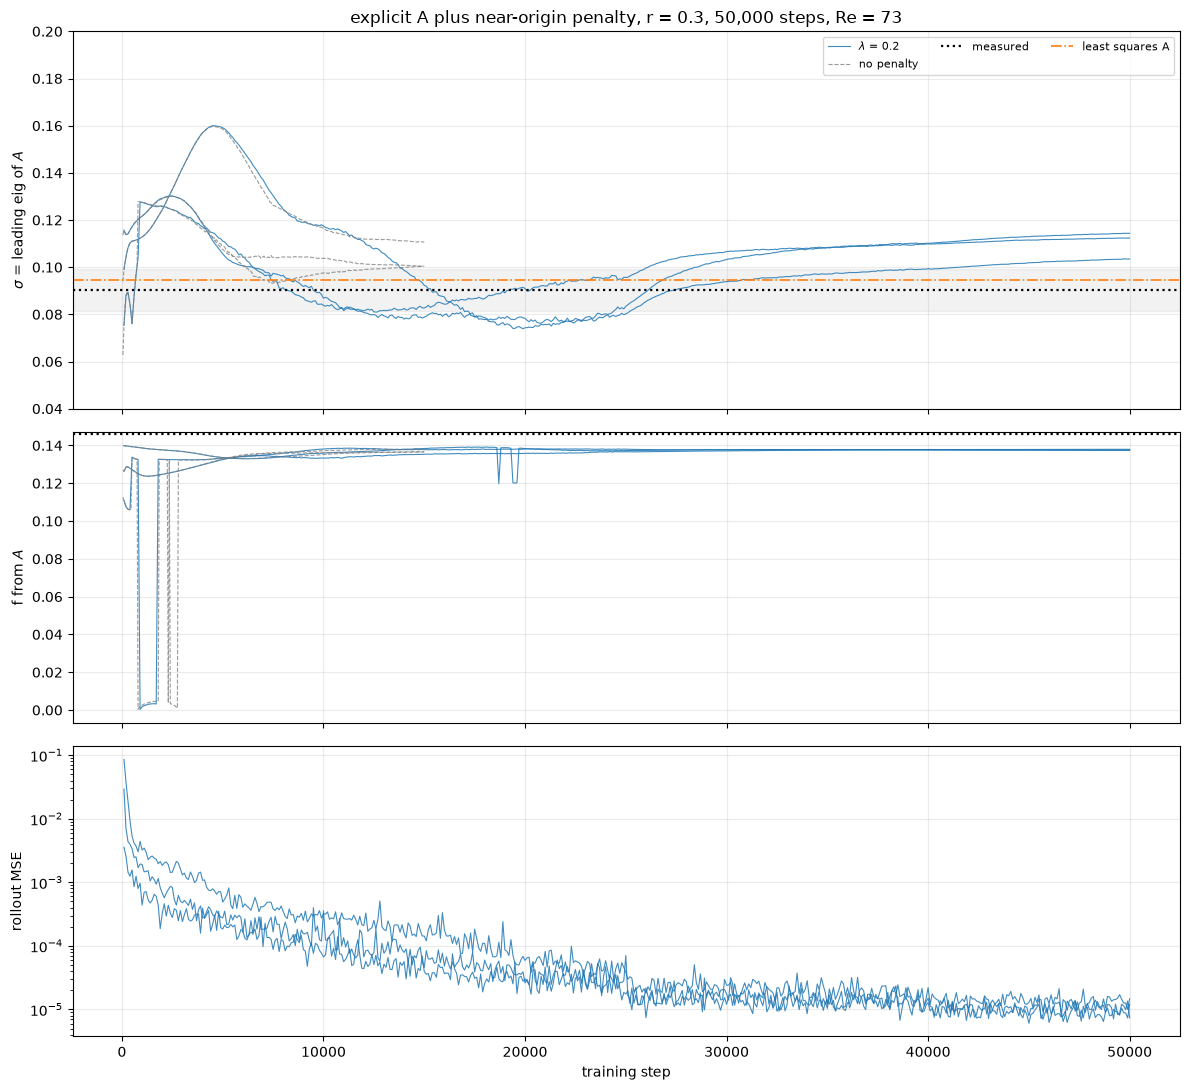

| model | mean sigma | bias | seed spread | wander (late) | mean f | f bias | rollout MSE |
|---:|---:|---:|---:|---:|---:|---:|---:|
| no penalty (15k) | +0.1038 | +15% | 0.0103 | 0.0190 | 0.1371 | -6% | 1.19e-04 |
| lambda = 0.2 | +0.1101 | +22% | 0.0108 | 0.0205 | 0.1376 | -6% | 1.14e-05 |

measured sigma +0.0903, measured f 0.1462, least squares A gives +0.0946

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(12, 11), sharex=True,
                       gridspec_kw={'height_ratios': [2.6, 2, 2]})
cols = {PEN_LAMBDA: 'C0'}
for lam in PEN_LAMBDAS:
    for s in PEN_SEEDS:
        st = np.array(sorted(pen_tracks[(lam, s)]))
        t = pen_tracks[(lam, s)]
        lab = f'$\\lambda$ = {lam}' if s == PEN_SEEDS[0] else None
        ax[0].plot(st, [t[k][0] for k in st], lw=0.8, alpha=0.85, color=cols[lam], label=lab)
        ax[1].plot(st, [t[k][1] for k in st], lw=0.8, alpha=0.85, color=cols[lam])
        ax[2].semilogy(st, [t[k][2] for k in st], lw=0.8, alpha=0.85, color=cols[lam])
for s in PEN_SEEDS:
    st = np.array(sorted(lin_tracks[('warm', s)]))
    ax[0].plot(st, [lin_tracks[('warm', s)][k][0] for k in st], color='0.5', ls='--', lw=0.8,
               alpha=0.8, label='no penalty' if s == PEN_SEEDS[0] else None)
    ax[1].plot(st, [lin_tracks[('warm', s)][k][1] for k in st], color='0.5', ls='--',
               lw=0.8, alpha=0.8)
ax[0].axhline(SIGMA_MEAS, color='k', ls=':', lw=1.6, label='measured')
ax[0].axhspan(0.9*SIGMA_MEAS, 1.1*SIGMA_MEAS, color='0.6', alpha=0.12)
ax[0].axhline(_s, color='C1', ls='-.', lw=1.2, label='least squares A')
ax[1].axhline(F_LIN_MEAS, color='k', ls=':', lw=1.6)
ax[0].set_ylabel(r'$\sigma$ = leading eig of $A$'); ax[0].set_ylim(0.04, 0.20)
ax[1].set_ylabel('f from $A$'); ax[2].set_ylabel('rollout MSE')
ax[2].set_xlabel('training step'); ax[0].legend(fontsize=8, ncol=3)
ax[0].set_title(f'explicit A plus near-origin penalty, r = {PEN_R}, '
                f'{PEN_STEPS:,} steps, Re = {RE:g}')
for a in ax: a.grid(alpha=0.25)
plt.tight_layout(); plt.show()

rows = []
def add(v, fv, main, lab):
    late = np.concatenate(v[1])
    rows.append([lab, f'{np.mean(v[0]):+.4f}',
                 f'{100*(np.mean(v[0])-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%', f'{np.ptp(v[0]):.4f}',
                 f'{np.ptp(late):.4f}', f'{np.mean(fv):.4f}',
                 f'{100*(np.mean(fv)-F_LIN_MEAS)/F_LIN_MEAS:+.0f}%', f'{np.mean(main):.2e}'])
w = ([lin_tracks[('warm', s)][15000][0] for s in PEN_SEEDS],
     [[lin_tracks[('warm', s)][k][0] for k in sorted(lin_tracks[('warm', s)]) if k > 10000]
      for s in PEN_SEEDS])
add(w, [lin_tracks[('warm', s)][15000][1] for s in PEN_SEEDS],
    [lin_tracks[('warm', s)][15000][2] for s in PEN_SEEDS], 'no penalty (15k)')
for lam in PEN_LAMBDAS:
    v = ([pen_tracks[(lam, s)][PEN_STEPS][0] for s in PEN_SEEDS],
         [[pen_tracks[(lam, s)][k][0] for k in sorted(pen_tracks[(lam, s)]) if k > 0.6*PEN_STEPS]
          for s in PEN_SEEDS])
    add(v, [pen_tracks[(lam, s)][PEN_STEPS][1] for s in PEN_SEEDS],
        [pen_tracks[(lam, s)][PEN_STEPS][2] for s in PEN_SEEDS], f'lambda = {lam}')
table(['model', 'mean sigma', 'bias', 'seed spread', 'wander (late)', 'mean f', 'f bias',
       'rollout MSE'], ['---:']*8, rows,
      caption=f'measured sigma {SIGMA_MEAS:+.4f}, measured f {F_LIN_MEAS:.4f}, '
              f'least squares A gives {_s:+.4f}')

## Did the penalty actually make the field linear?

Sigma is still wrong, so it is worth checking whether the penalty did what it was built to do.
Evaluate the leading oscillatory eigenvalue of $J(z)$ along the trajectory, out to $|z| = 0.6$,
and compare the plain NODE against both structured versions. Over this range the truth is a
horizontal line at the measured value, to within 0.6%.

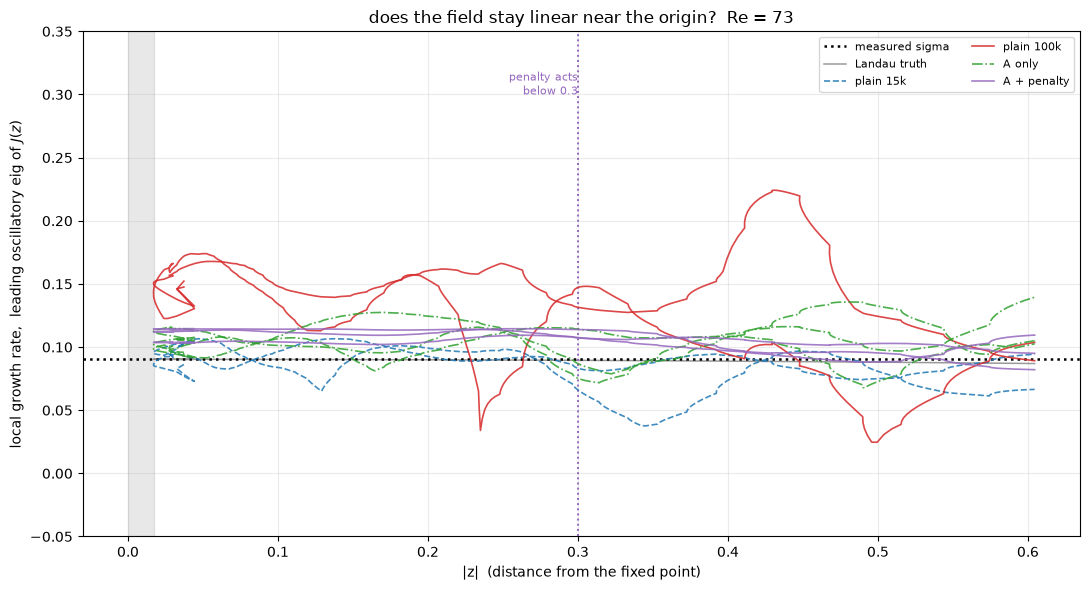

In [10]:
def densify(path, k=8):
    seg = [path[j] + (path[j+1] - path[j]) * (q/k)
           for j in range(len(path)-1) for q in range(k)]
    seg.append(path[-1]); return np.asarray(seg)

def f_of(key):
    prm = _cache[key][0]
    if isinstance(prm, dict):                      # explicit-A model
        hp, A = prm['h'], jnp.asarray(prm['A'])
        z0 = jnp.zeros(R); h0 = h_net(hp, z0)
        J0 = jax.jacfwd(lambda z: h_net(hp, z))(z0)
        return lambda z: A @ z + h_net(hp, z) - h0 - J0 @ z
    return lambda z: f(prm, z)                     # plain NODE

def sig_at(fn, z):
    ev = np.linalg.eigvals(np.asarray(jax.jacfwd(fn)(jnp.asarray(z, dtype=jnp.float64))))
    o = ev[np.abs(ev.imag) > 1e-6]
    return o[np.argmax(o.real)].real if len(o) else np.nan

out_tr = runs[0]; amp_tr = np.linalg.norm(out_tr, axis=1)
A_SAT = amp_tr[int(0.75*len(amp_tr)):].mean()
sel = amp_tr < 0.62; dense = densify(out_tr[sel]); ad = np.linalg.norm(dense, axis=1)

GROUPS = [('plain 15k',  [f'Re{RE:g}_mb128_L9_seed{s}_15000'  for s in (3, 4)], 'C0', '--'),
          ('plain 100k', [f'Re{RE:g}_mb128_L9_seed{s}_100000' for s in (3, 4)], 'C3', '-'),
          ('A only',     [f'Re{RE:g}_linA_warm_seed{s}_15000' for s in LIN_SEEDS], 'C2', '-.'),
          ('A + penalty',[f'Re{RE:g}_pen{PEN_LAMBDA}_seed{s}_{PEN_STEPS}' for s in PEN_SEEDS],
                         'C4', '-')]
fig, ax = plt.subplots(figsize=(11, 6))
ax.axhline(SIGMA_MEAS, color='k', ls=':', lw=1.8, label='measured sigma')
ax.plot(amp_tr[sel], SIGMA_MEAS*(1 - (amp_tr[sel]/A_SAT)**2), color='k', lw=1.1, alpha=0.4,
        label='Landau truth')
ax.axvspan(0, amp_tr.min(), color='0.55', alpha=0.20)
ax.axvline(PEN_R, color='C4', ls=':', lw=1.4)
ax.annotate(f'penalty acts\nbelow {PEN_R}', (PEN_R, 0.30), fontsize=8, ha='right', color='C4')
for lab, keys, col, ls in GROUPS:
    for j, k in enumerate(keys):
        fn = f_of(k)
        ax.plot(ad, [sig_at(fn, z) for z in dense], color=col, ls=ls, lw=1.2, alpha=0.85,
                label=lab if j == 0 else None)
ax.set_xlabel('|z|  (distance from the fixed point)')
ax.set_ylabel(r'local growth rate,  leading oscillatory eig of $J(z)$')
ax.set_title(f'does the field stay linear near the origin?  Re = {RE:g}')
ax.set_ylim(-0.05, 0.35); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

The penalty did its job. The purple curves are flat to about 0.01 across the whole
range, and they stay flat well past 0.3 where the penalty stops acting, so the model is not
fighting the constraint at the boundary. Green, with the explicit $A$ but no penalty, is
smoother than the plain NODE and still visibly wavy. Red, the plain 100k fit, swings from 0.03
to 0.22.

They are flat at the wrong height. Purple sits near 0.11 against a measured 0.0903.

So the curvature was never the problem. We stopped the field bending near the origin and sigma
was just as wrong afterwards, which is worth knowing: a confidently linear field with the wrong
slope is what this objective converges to.

### What the constrained field does to the trajectory

Same free rollout as notebook 2, from the first state only, all 8 modes. Black is the data,
green is the explicit $A$ with nothing else, purple adds the near origin penalty. The plain
NODE at 15k is in grey for scale, since that is the model whose sigma is right.

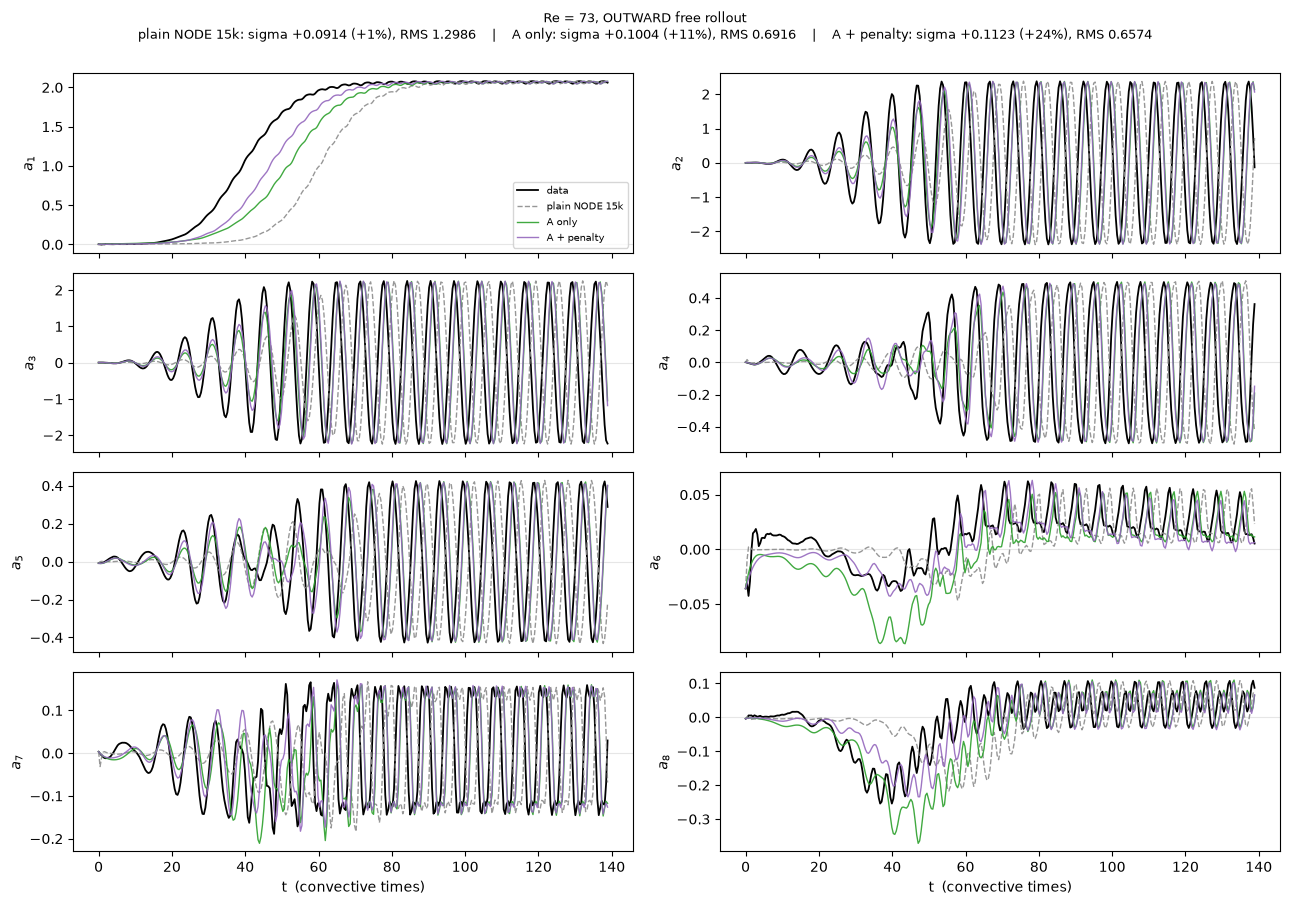

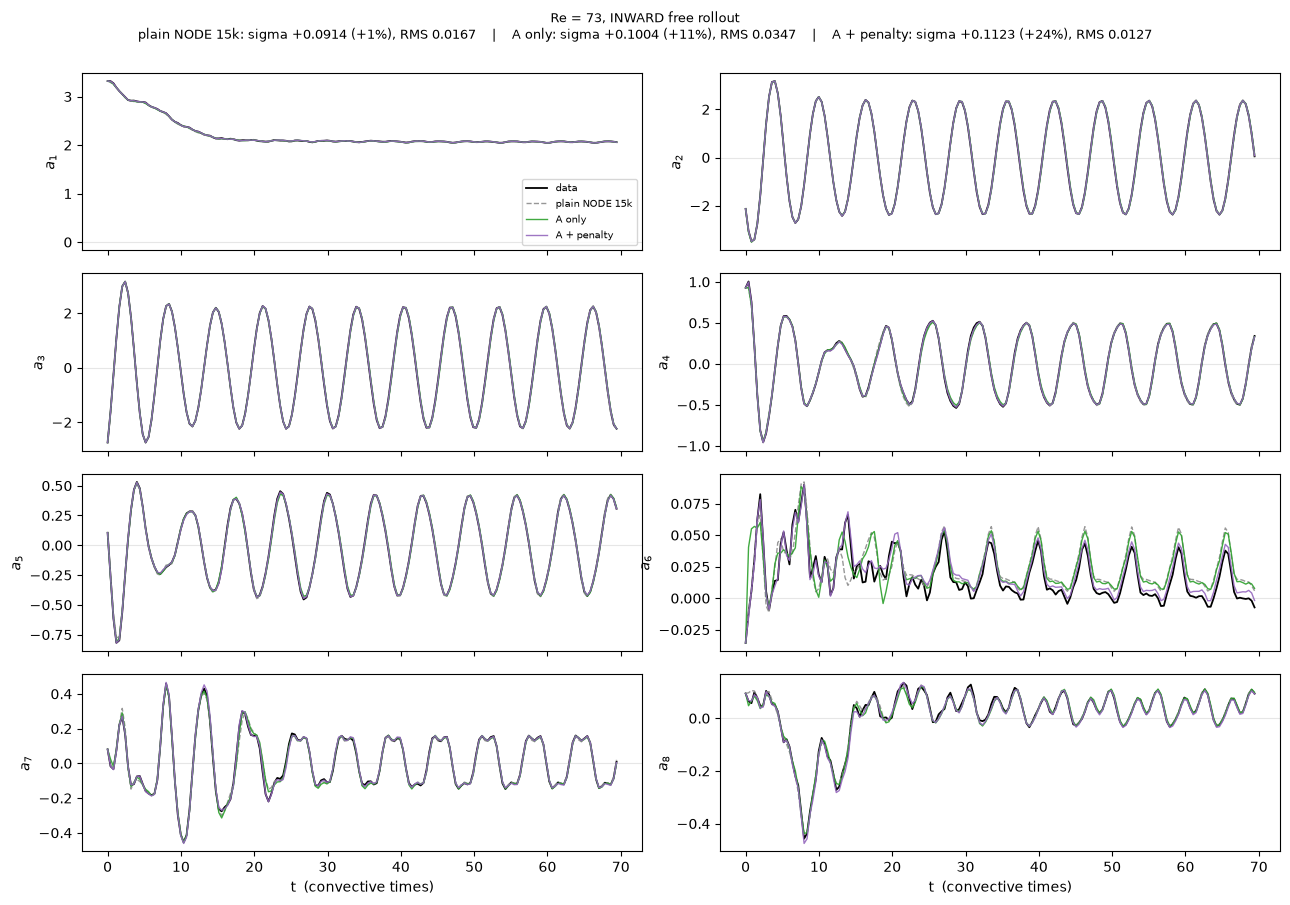

In [11]:
def integrate(fn, z0, n):
    def stp(z):
        for _ in range(SUBSTEPS):
            dt = DT / SUBSTEPS
            k1 = fn(z); k2 = fn(z + .5*dt*k1); k3 = fn(z + .5*dt*k2); k4 = fn(z + dt*k3)
            z = z + (dt/6.)*(k1 + 2*k2 + 2*k3 + k4)
        return z
    _, tj = jax.lax.scan(lambda z, _: (stp(z),)*2, z0, None, length=n)
    return np.asarray(jnp.concatenate([z0[None], tj]))

ROLL = [('plain NODE 15k', f'Re{RE:g}_mb128_L9_seed3_15000',                     '0.55', '--'),
        ('A only',         f'Re{RE:g}_linA_warm_seed0_15000',                    'C2',   '-'),
        ('A + penalty',    f'Re{RE:g}_pen{PEN_LAMBDA}_seed0_{PEN_STEPS}',        'C4',   '-')]

for name, truth in (('outward', runs[0]), ('inward', runs[1])):
    t = np.arange(len(truth)) * DT
    z0 = jnp.asarray(truth[0], dtype=jnp.float64)
    curves = []
    for lab, key, col, ls in ROLL:
        fn = f_of(key)
        rl = integrate(fn, z0, len(truth) - 1)
        curves.append((lab, rl, col, ls, float(np.sqrt(np.mean((rl - truth)**2))),
                       sig_at(fn, np.zeros(R))))
    fig, axes = plt.subplots(4, 2, figsize=(13, 9), sharex=True)
    for i, ax in enumerate(axes.ravel()):
        ax.plot(t, truth[:, i], 'k', lw=1.3, label='data')
        for lab, rl, col, ls, _, _ in curves:
            ax.plot(t, rl[:, i], color=col, ls=ls, lw=1.0, alpha=0.9, label=lab)
        ax.axhline(0, color='0.9', lw=0.8, zorder=0)
        ax.set_ylabel(f'$a_{{{i+1}}}$')
        if i == 0:
            ax.legend(loc='lower right', fontsize=7.5)
    for ax in axes[-1]:
        ax.set_xlabel('t  (convective times)')
    sub = '    |    '.join(f'{lab}: sigma {sg:+.4f} '
                           f'({100*(sg-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%), RMS {e:.4f}'
                           for lab, _, _, _, e, sg in curves)
    fig.suptitle(f'Re = {RE:g}, {name.upper()} free rollout\n{sub}', y=1.0, fontsize=9)
    plt.tight_layout(); plt.show()

In [12]:
rows = []
for lab, key in [('plain NODE 15k',    f'Re{RE:g}_mb128_L9_seed3_15000'),
                 ('plain NODE 100k',   f'Re{RE:g}_mb128_L9_seed3_100000'),
                 ('A only',            f'Re{RE:g}_linA_warm_seed0_15000'),
                 ('A + penalty',       f'Re{RE:g}_pen{PEN_LAMBDA}_seed0_{PEN_STEPS}')]:
    fn = f_of(key)
    def stp(z):
        for _ in range(SUBSTEPS):
            k1 = fn(z); k2 = fn(z + .5*(DT/SUBSTEPS)*k1)
            k3 = fn(z + .5*(DT/SUBSTEPS)*k2); k4 = fn(z + (DT/SUBSTEPS)*k3)
            z = z + ((DT/SUBSTEPS)/6.)*(k1 + 2*k2 + 2*k3 + k4)
        return z
    errs = []
    for truth in runs:
        z0 = jnp.asarray(truth[0], dtype=jnp.float64)
        _, tj = jax.lax.scan(lambda z, _: (stp(z),)*2, z0, None, length=len(truth)-1)
        rl = np.asarray(jnp.concatenate([z0[None], tj]))
        errs.append(float(np.sqrt(np.mean((rl - truth)**2))))
    sg = sig_at(fn, np.zeros(R))
    rows.append([lab, f'{sg:+.4f}', f'{100*(sg-SIGMA_MEAS)/SIGMA_MEAS:+.0f}%',
                 f'{errs[0]:.4f}', f'{errs[1]:.4f}'])
table(['model', 'sigma', 'sigma error', 'outward rollout RMS', 'inward rollout RMS'],
      ['---:']*5, rows,
      caption='Read down the table. Rollout quality and sigma accuracy move in opposite '
              'directions across four quite different models.')

| model | sigma | sigma error | outward rollout RMS | inward rollout RMS |
|---:|---:|---:|---:|---:|
| plain NODE 15k | +0.0914 | +1% | 1.2986 | 0.0167 |
| plain NODE 100k | +0.1560 | +73% | 0.3036 | 0.0040 |
| A only | +0.1004 | +11% | 0.6916 | 0.0347 |
| A + penalty | +0.1123 | +24% | 0.6574 | 0.0127 |

Read down the table. Rollout quality and sigma accuracy move in opposite directions across four quite different models.